/var/folders/cr/p_hncrm51f7dh4hgrpllv5y40000gn/T/ipykernel_1471/3099799554.py:39: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


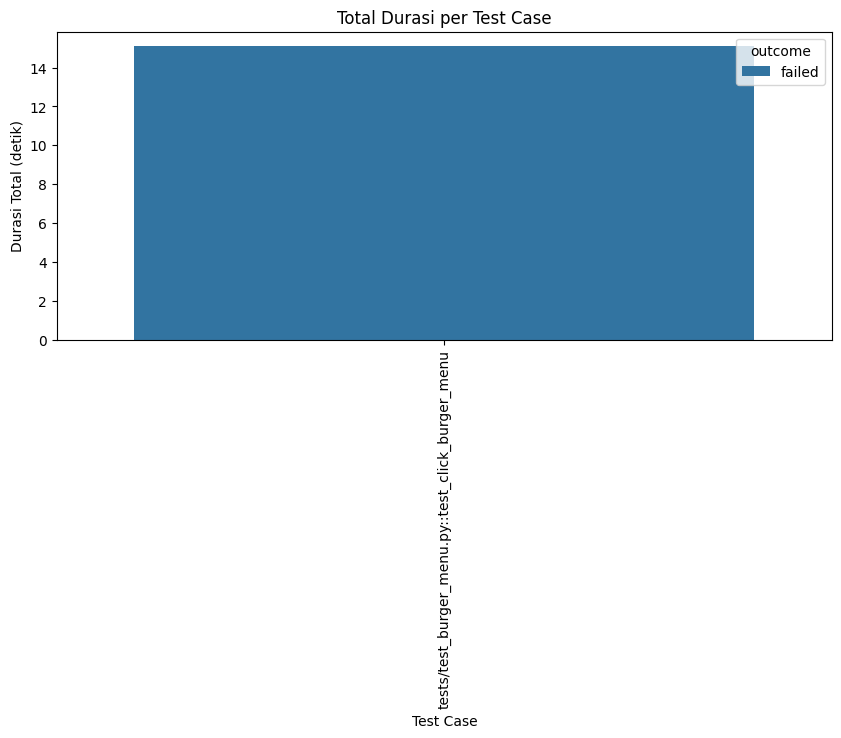

,nodeid,outcome,duration
0,tests/test_burger_menu.py::test_click_burger_menu,failed,0.000698


In [ ]:
# 📊 Dashboard Test Report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Load JSON report
with open('reports/report.json') as f:
    data = json.load(f)

results = data.get('tests', [])
df = pd.DataFrame(results)
df['outcome'] = df['outcome'].fillna('unknown')
# df['duration'] = df['duration'].fillna(0)

# Ambil durasi dari call section
df['duration'] = df['call'].apply(lambda x: x.get('duration', 0) if isinstance(x, dict) else 0)

def total_duration(row):
    d = 0
    for phase in ['setup', 'call', 'teardown']:
        if isinstance(row.get(phase), dict):
            d += row[phase].get('duration', 0)
    return d

df['total_duration'] = df.apply(total_duration, axis=1)


df.head()
outcome_counts = df['outcome'].value_counts()

# # 📊 Bar Chart Total Durasi Test (Setup + Call + Teardown)
# plt.figure(figsize=(10, 4))
# sns.barplot(data=df, x='nodeid', y='total_duration', hue='outcome', dodge=False)
# plt.xticks(rotation=90)
# plt.title('Total Durasi per Test Case')
# plt.ylabel('Durasi Total (detik)')
# plt.xlabel('Test Case')
# plt.tight_layout()
# plt.show()


plt.figure(figsize=(6, 6))
plt.pie(outcome_counts, labels=outcome_counts.index, autopct='%1.1f%%', startangle=140, colors=['#4CAF50', '#F44336'])
plt.title('Distribusi Hasil Test')
plt.axis('equal')
plt.show()
plt.figure(figsize=(10, 4))
sns.barplot(data=df, x='nodeid', y='duration', hue='outcome', dodge=False)
plt.xticks(rotation=90)
plt.title('Durasi per Test Case')
plt.ylabel('Durasi (detik)')
plt.xlabel('Test Case')
plt.tight_layout()
plt.show()
df[['nodeid', 'outcome', 'duration']].sort_values(by='outcome')